# Gaming a one-stage selective admissions system

This notebook reproduces the no-commitment, one-stage continuum model on printed pages 5–8 of Lee and Suen. The paper is authoritative. Every reported equilibrium and outcome is generated by the tested `admissions_simulation` engine; the finite-population section is validation, not a separate equilibrium concept.

The notebook follows the approved **Simulation lab** flow: declare one parameter source, show every equilibrium, select only the largest locally stable equilibrium for comparative statics, report distinct outcome concepts, and then check finite-population convergence.

In [1]:
from dataclasses import fields
import math

import matplotlib.pyplot as plt
import numpy as np

from admissions_simulation import (
    Scenario,
    UniformCostDistribution,
    analyze_scenario,
    run_monte_carlo_validation,
)

plt.style.use('seaborn-v0_8-whitegrid')

## Authoritative parameters

The benefit of admission and upper tutoring-cost support are both `B = 1`; the high-ability share is `λ = 0.3`; and costs are uniform, so `F(c) = c/B`. Paper Figure 1 compares `Q = 0.33` with `Q = 0.40`. The derivative notes' `Q = 0.40, 0.50` comparison is kept separate.

For a candidate cutoff `S`, the university first fills its quota from high scorers. The fixed point is `S = B(X − Y)`, where `X` and `Y` are admission probabilities conditional on high and low scores.

In [2]:
B = 1.0
LAMBDA = 0.3
PAPER_QUOTAS = (0.33, 0.40)
NOTES_QUOTAS = (0.40, 0.50)
COST_DISTRIBUTION = UniformCostDistribution(upper=B)
SELECTION_RULE = 'largest locally stable equilibrium'

def scenario_for(quota):
    return Scenario(
        benefit=B,
        high_ability_share=LAMBDA,
        university_quota=quota,
    )

def analyze_quotas(quotas):
    return {
        quota: analyze_scenario(scenario_for(quota), COST_DISTRIBUTION)
        for quota in quotas
    }

paper_analyses = analyze_quotas(PAPER_QUOTAS)
notes_analyses = analyze_quotas(NOTES_QUOTAS)

print(f'B={B:g}, λ={LAMBDA:g}, F(c)=c/B, selection={SELECTION_RULE}')

B=1, λ=0.3, F(c)=c/B, selection=largest locally stable equilibrium


## Metric definitions

These quantities are deliberately kept separate:

- **Equilibrium tutoring-cost cutoff `S*`**: the highest cost at which a low-ability student chooses tutoring.
- **Low-ability tutoring participation rate `F(S*)`**: the share of low-ability students who tutor.
- **Population tutoring mass `(1 − λ)F(S*)`**: the population share that tutors.
- **High-/low-score admission probabilities `X`, `Y`**: admission conditional on the observed score.
- **Credibility**: the posterior probability of high ability conditional on a high score.
- **Admitted high-ability share**: high-ability students as a share of the admitted class.
- **Aggregate tutoring expenditure**: total tutoring costs paid across the population, not a participation measure.

In [3]:
EQUILIBRIUM_COLUMNS = (
    'scenario', 'branch', 'selected', 'S*', 'F(S*)', '(1-λ)F(S*)',
    'regime', 'stability', 'X', 'Y', 'credibility',
    'admitted high-ability share', 'aggregate tutoring expenditure',
)

def equilibrium_rows(analyses, label):
    rows = []
    for quota, analysis in analyses.items():
        for branch, equilibrium in enumerate(analysis.equilibria, start=1):
            outcome = equilibrium.outcomes
            rows.append((
                f'{label} Q={quota:.2f}',
                str(branch),
                'yes' if equilibrium is analysis.selected_equilibrium else '',
                f'{equilibrium.tutoring_cost_cutoff:.6f}',
                f'{outcome.low_ability_tutoring_participation_rate:.6f}',
                f'{outcome.population_tutoring_mass:.6f}',
                equilibrium.regime.value,
                equilibrium.stability.value,
                f'{equilibrium.high_score_admission_probability:.6f}',
                f'{equilibrium.low_score_admission_probability:.6f}',
                f'{outcome.credibility:.6f}',
                f'{outcome.admitted_high_ability_share:.6f}',
                f'{outcome.aggregate_tutoring_expenditure:.6f}',
            ))
    return rows

def print_table(columns, rows):
    widths = [max(len(str(value)) for value in (column, *(row[i] for row in rows))) for i, column in enumerate(columns)]
    def line(row):
        return ' | '.join(str(value).ljust(width) for value, width in zip(row, widths))
    print(line(columns))
    print('-+-'.join('-' * width for width in widths))
    for row in rows:
        print(line(row))

## Paper Figure 1 reproduction

Figure 1 plots the tutoring benefit `β(S, Q) = B(X − Y)` against the 45-degree line. It shows that when `Q > λ`, the response rises under a loose quota and falls under a tight quota. Increasing `Q` shifts the response to the right and raises `S*` in the largest equilibrium. All roots are marked; the filled marker is the selected largest stable root.

In [4]:
paper_rows = equilibrium_rows(paper_analyses, 'Paper')
print_table(EQUILIBRIUM_COLUMNS, paper_rows)

scenario     | branch | selected | S*       | F(S*)    | (1-λ)F(S*) | regime | stability | X        | Y        | credibility | admitted high-ability share | aggregate tutoring expenditure
-------------+--------+----------+----------+----------+------------+--------+-----------+----------+----------+-------------+-----------------------------+-------------------------------
Paper Q=0.33 | 1      | yes      | 0.504983 | 0.504983 | 0.353488   | tight  | stable    | 0.504983 | 0.000000 | 0.459075    | 0.459075                    | 0.089253                      
Paper Q=0.40 | 1      | yes      | 0.571429 | 0.571429 | 0.400000   | tight  | stable    | 0.571429 | 0.000000 | 0.428571    | 0.428571                    | 0.114286                      


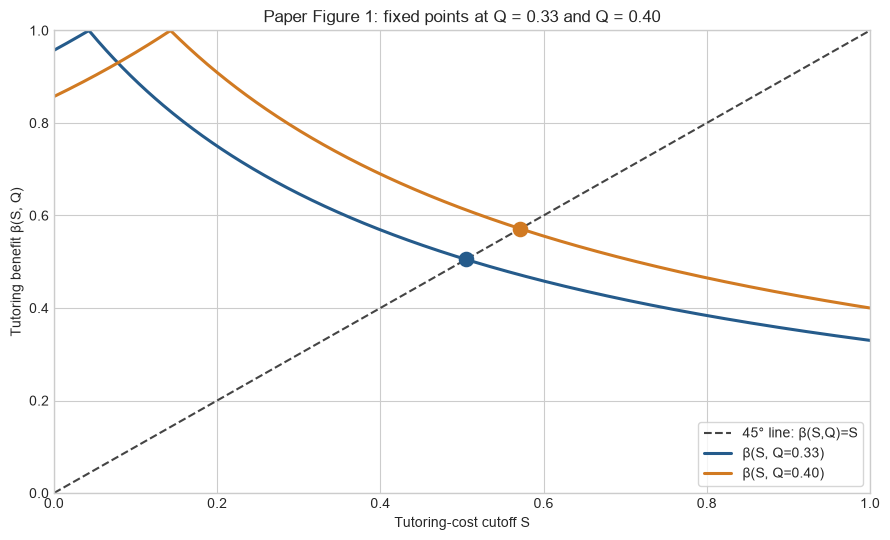

In [5]:
def tutoring_benefit(cutoff, quota):
    participation = COST_DISTRIBUTION.cdf(cutoff)
    high_scorer_mass = LAMBDA + (1.0 - LAMBDA) * participation
    if quota > high_scorer_mass:
        low_score_admission = (quota - high_scorer_mass) / (1.0 - high_scorer_mass)
        high_score_admission = 1.0
    else:
        high_score_admission = quota / high_scorer_mass
        low_score_admission = 0.0
    return B * (high_score_admission - low_score_admission)

def plot_fixed_points(analyses, title):
    cutoffs = np.linspace(0.0, B, 501)
    figure, axis = plt.subplots(figsize=(9, 5.5))
    axis.plot(cutoffs, cutoffs, color='#444444', linestyle='--', label='45° line: β(S,Q)=S')
    colors = ('#255b8b', '#d17a22', '#39745a', '#8d5a97')
    for color, (quota, analysis) in zip(colors, analyses.items()):
        benefits = [tutoring_benefit(cutoff, quota) for cutoff in cutoffs]
        axis.plot(cutoffs, benefits, color=color, linewidth=2.2, label=f'β(S, Q={quota:.2f})')
        for equilibrium in analysis.equilibria:
            selected = equilibrium is analysis.selected_equilibrium
            axis.scatter(
                equilibrium.tutoring_cost_cutoff,
                equilibrium.tutoring_cost_cutoff,
                s=85 if selected else 55,
                facecolor=color if selected else 'white',
                edgecolor=color, linewidth=2, zorder=5,
            )
    axis.set(xlim=(0, B), ylim=(0, B), xlabel='Tutoring-cost cutoff S', ylabel='Tutoring benefit β(S, Q)', title=title)
    axis.legend(frameon=True)
    figure.tight_layout()
    plt.show()

plot_fixed_points(paper_analyses, 'Paper Figure 1: fixed points at Q = 0.33 and Q = 0.40')

### Every equilibrium branch

The two Figure 1 presets each have one stable tight-quota equilibrium. To make the engine's exhaustive branch behavior reviewable, the diagnostic below raises the quota to `Q = 0.85`, where the same uniform model has stable loose, unstable loose, and stable tight equilibria. This is a branch diagnostic, not a paper Figure 1 calibration.

scenario          | branch | selected | S*       | F(S*)    | (1-λ)F(S*) | regime | stability | X        | Y        | credibility | admitted high-ability share | aggregate tutoring expenditure
------------------+--------+----------+----------+----------+------------+--------+-----------+----------+----------+-------------+-----------------------------+-------------------------------
Diagnostic Q=0.85 | 1      |          | 0.311018 | 0.311018 | 0.217712   | loose  | stable    | 1.000000 | 0.688982 | 0.579472    | 0.352941                    | 0.033856                      
Diagnostic Q=0.85 | 2      |          | 0.688982 | 0.688982 | 0.482288   | loose  | unstable  | 1.000000 | 0.311018 | 0.383491    | 0.352941                    | 0.166144                      
Diagnostic Q=0.85 | 3      | yes      | 0.908302 | 0.908302 | 0.635812   | tight  | stable    | 0.908302 | 0.000000 | 0.320577    | 0.320577                    | 0.288755                      


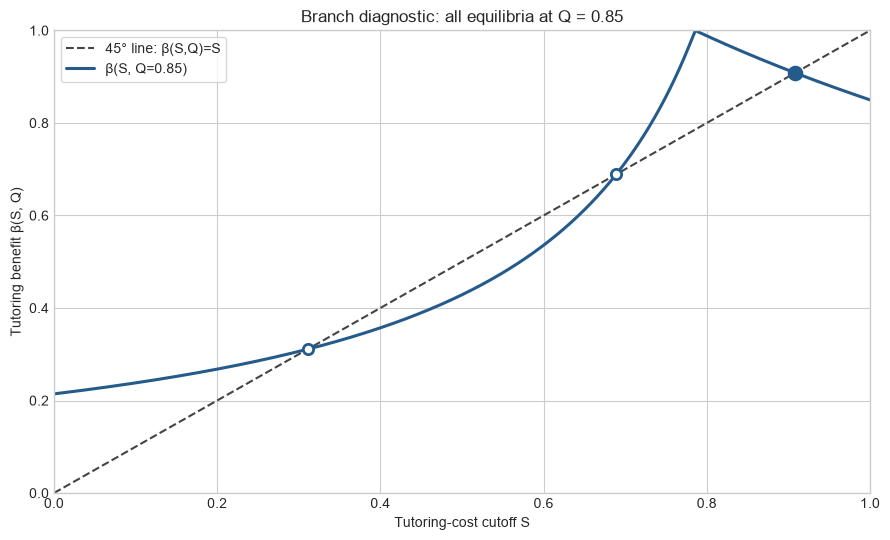

In [6]:
branch_diagnostic = analyze_quotas((0.85,))
print_table(EQUILIBRIUM_COLUMNS, equilibrium_rows(branch_diagnostic, 'Diagnostic'))
plot_fixed_points(branch_diagnostic, 'Branch diagnostic: all equilibria at Q = 0.85')

## Notes scenario (secondary)

The derivative notes compare `Q = 0.40` and `Q = 0.50`. This is evaluated separately and does not replace the paper's `Q = 0.33, 0.40` Figure 1 values.

scenario     | branch | selected | S*       | F(S*)    | (1-λ)F(S*) | regime | stability | X        | Y        | credibility | admitted high-ability share | aggregate tutoring expenditure
-------------+--------+----------+----------+----------+------------+--------+-----------+----------+----------+-------------+-----------------------------+-------------------------------
Notes Q=0.40 | 1      | yes      | 0.571429 | 0.571429 | 0.400000   | tight  | stable    | 0.571429 | 0.000000 | 0.428571    | 0.428571                    | 0.114286                      
Notes Q=0.50 | 1      | yes      | 0.657611 | 0.657611 | 0.460328   | tight  | stable    | 0.657611 | 0.000000 | 0.394567    | 0.394567                    | 0.151358                      


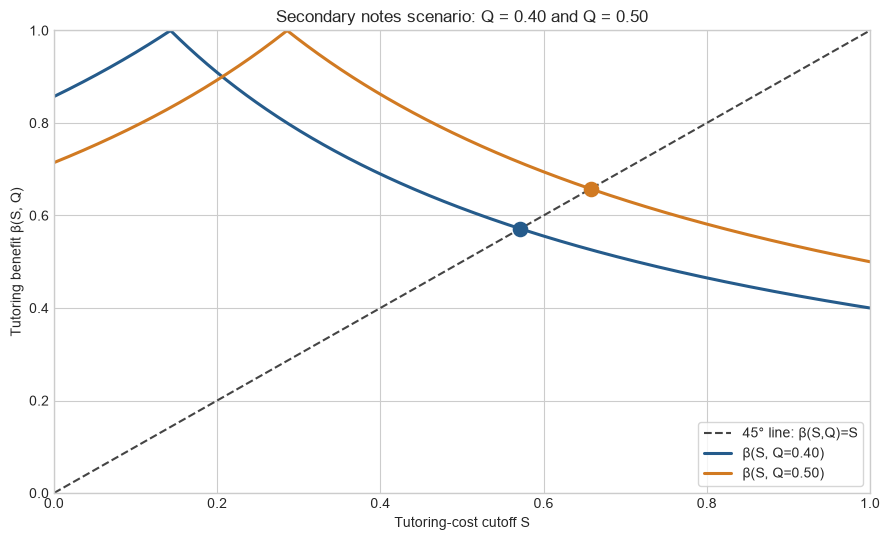

In [7]:
notes_rows = equilibrium_rows(notes_analyses, 'Notes')
print_table(EQUILIBRIUM_COLUMNS, notes_rows)
plot_fixed_points(notes_analyses, 'Secondary notes scenario: Q = 0.40 and Q = 0.50')

## Finite-population validation

Each seeded finite-population realization samples tutoring costs around the **selected continuum equilibrium** while holding `λ` and `Q` at exact integer counts. The continuum result remains authoritative. Falling cutoff RMSE as `N` grows is evidence that the sampled realization converges toward it; it does not define a finite-population equilibrium.

Increase `MC_TRIALS` for publication runs. The default is intentionally modest so a clean notebook run remains quick.

In [8]:
MC_POPULATION_SIZES = (100, 1000)
MC_TRIALS = 25
MC_SEED = 1729

validation_results = {
    quota: run_monte_carlo_validation(
        scenario_for(quota),
        COST_DISTRIBUTION,
        population_sizes=MC_POPULATION_SIZES,
        trials=MC_TRIALS,
        seed=MC_SEED,
    )
    for quota in PAPER_QUOTAS
}

validation_columns = ('Q', 'N', 'trials', 'regime agreement', 'cutoff mean', 'cutoff bias', 'cutoff RMSE', 'cutoff SE')
validation_rows = []
for quota, validation in validation_results.items():
    for summary in validation.population_summaries:
        cutoff = summary.tutoring_cost_cutoff
        validation_rows.append((
            f'{quota:.2f}', str(summary.population_size), str(summary.trials),
            f'{summary.regime_agreement_rate:.3f}', f'{cutoff.mean:.6f}',
            f'{cutoff.bias:+.6f}', f'{cutoff.root_mean_squared_error:.6f}',
            f'{cutoff.standard_error:.6f}',
        ))
print_table(validation_columns, validation_rows)

Q    | N    | trials | regime agreement | cutoff mean | cutoff bias | cutoff RMSE | cutoff SE
-----+------+--------+------------------+-------------+-------------+-------------+----------
0.33 | 100  | 25     | 1.000            | 0.504274    | -0.000708   | 0.007386    | 0.001501 
0.33 | 1000 | 25     | 1.000            | 0.504975    | -0.000007   | 0.000846    | 0.000173 
0.40 | 100  | 25     | 1.000            | 0.572372    | +0.000943   | 0.008333    | 0.001690 
0.40 | 1000 | 25     | 1.000            | 0.571470    | +0.000041   | 0.001031    | 0.000210 


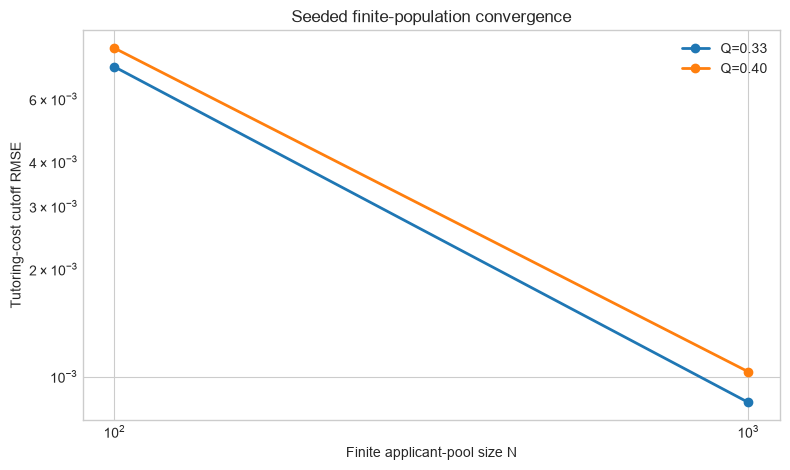

In [9]:
figure, axis = plt.subplots(figsize=(8, 4.8))
for quota, validation in validation_results.items():
    sizes = [summary.population_size for summary in validation.population_summaries]
    errors = [summary.tutoring_cost_cutoff.root_mean_squared_error for summary in validation.population_summaries]
    axis.loglog(sizes, errors, marker='o', linewidth=2, label=f'Q={quota:.2f}')
axis.set(xlabel='Finite applicant-pool size N', ylabel='Tutoring-cost cutoff RMSE', title='Seeded finite-population convergence')
axis.legend()
figure.tight_layout()
plt.show()

## Reproduction checklist

- Paper Figure 1 values are evaluated before the notes extension.
- Every equilibrium is tabulated with regime and local best-response stability.
- The largest stable equilibrium is selected only for comparative-static and validation summaries.
- Tutoring cutoff, low-ability participation, population tutoring mass, admission probabilities, credibility, admitted high-ability share, and aggregate tutoring expenditure remain distinct.
- Seed and finite population sizes are visible and editable.
- Re-running from the repository root regenerates all values and plots from tested public model interfaces.